# Initialize Notebook

In [ ]:
import matplotlib.pyplot as plt
import torch
import os
from pathlib import Path
from importlib import reload
import numpy as np

from pathlib import Path
import sys

# Repo root = parent of notebooks/
REPO_ROOT = Path.cwd().resolve().parent
SRC_PATH = REPO_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
    # sys.path.insert(0, str(SRC_PATH / 'project'))

import glori.settings.paths as paths

# Sample with Intermediates

## Prepare

Required imports

In [ ]:
from glori.plotting.images import plot_image_grid
from tqdm import tqdm, trange

import pandas as pd

import glori.analysis.ldm.resample as ldmr

reload(ldmr)
from glori.analysis.ldm.resample import load_mosaic_names, get_mosaic_blueprint

from importlib import import_module
import pandas as pd


def import_reload(module_name, package=None, attr=None):
    module = import_module(module_name, package=package)
    reload(module)
    if attr:
        return getattr(module, attr)
    return module

## Load necessary data

Define settings for sampling

In [ ]:
# Model settings
denoiser = "LDM-Denoiser-WnetCC-v5"
denoiser_ckpt = "last-best"
# uncond_denoiser = "LDM-Denoiser-Uncond-128"
uncond_denoiser = None
uncond_denoiser_ckpt = "best"
vae = "VQ-VAE-256-DR3opt-FT"

# Sampling settings
latent_size = 128
f_vae = 4
image_size = latent_size * f_vae
guidance_strength = 0.2
timesteps = 25
div_stride = 1
f_ext_ctxt = 2
resample_first = False
device = "cuda:2"
catalog_mode = "combined"  # options: "combined", "separate"
decoding_stride = None

# Sampling blueprint settings
sampling_steps = (6, 3)
mask_coverage = 0.5
mask_overlap = int(mask_coverage * latent_size)
stride = latent_size - mask_overlap
img_mask_overlap = int(mask_coverage * image_size)
img_stride = image_size - img_mask_overlap
latent_map_size = tuple(latent_size + (s - 1) * stride for s in sampling_steps)
img_map_size = tuple(s * f_vae for s in latent_map_size)
latent_map_height, latent_map_width = latent_map_size
batch_size = 4
max_beam_arcsec = 6
seed = 42


# Load scaler
from glori.data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

Load LoTSS catalog

In [ ]:
# Load LoTSS DR3 catalog
from glori.data.utils import load_lotss_catalog

lotss_cat = load_lotss_catalog(
    select_cols=[
        "Source_Name",
        "RA",
        "DEC",
        "Total_flux",
        "Peak_flux",
        "Maj",
        # "Mosaic_ID",
    ],
    path=paths.LOFAR_DATA_PARENT_HOPPER / "LoTSS_DR3_v0.5.srl.parquet",
)

Load sampling blueprint

In [25]:
# Load mosaic name
[mosaic] = load_mosaic_names(n_mosaics=1, seed=seed, max_beam_arcsec=max_beam_arcsec)
print(f"Selected mosaic: {mosaic}")

# Get mosaic blueprint
img_cut, ctxt_red, ctxt_cat = get_mosaic_blueprint(mosaic, img_map_size, cat=lotss_cat)

# Get extended context map
extended_ctxt_size = tuple(s + image_size * (f_ext_ctxt - 1) for s in img_map_size)
_, ext_ctxt_red, _ = get_mosaic_blueprint(mosaic, extended_ctxt_size, cat=lotss_cat)

Selected mosaic: P133+24


Load ICM Sampler

In [ ]:
import_reload("glori.models.diffusion.diffusion")
import_reload("glori.inference.dm_sampler")
import_reload("glori.config.swiit_config")
SWIITSampler = import_reload("glori.inference.swiit_sampler", attr="SWIITSampler")

swiit_sampler = SWIITSampler(
    denoiser=denoiser,
    denoiser_ckpt=denoiser_ckpt,
    uncond_denoiser=uncond_denoiser,
    uncond_denoiser_ckpt=uncond_denoiser_ckpt,
    vae=vae,
    device=device,
    image_size=image_size,
    f_vae=f_vae,
    div_stride=div_stride,
    f_ext_ctxt=f_ext_ctxt,
    mask_coverage=mask_coverage,
)

 10:57:13 (SWIITSampler) - INFO : No config provided, initializing default...
 10:57:13 (SWIITSampler) - INFO : Overriding config with provided kwargs...
 10:57:13 (SWIITSampler) - INFO : Loading model <LDM-Denoiser-WnetCC-v5> from checkpoint:
	best-train_step=00281021-val_loss=1.34910e+00.ckpt...
 10:57:21 (SWIITSampler) - INFO : Loading model <VQ-VAE-256-DR3opt-FT> from checkpoint:
	best-train_step=00460500-val_loss=1.56044e-01.ckpt...


VQLossWithDiscriminator running with hinge loss.


 10:57:22 (SWIITSampler) - INFO : Initializing diffusion sampler...
 10:57:22 (SWIITSampler) - INFO : ICM Sampler initialized.


Paramaters

In [ ]:
model = swiit_sampler.denoiser.model.model

# Print number of parameters
n_params_model = sum(p.numel() for p in model.parameters())
n_params_catalog_emb = sum(p.numel() for p in model.catalog_emb.parameters())
n_params_unet = n_params_model - n_params_catalog_emb


print(f"Number of parameters in model: {n_params_model:,}")
print(f"Number of parameters in catalog embedding: {n_params_catalog_emb:,}")
print(f"Number of parameters in UNet: {n_params_unet:,}")

## Run ICM sampling & Plot

In [ ]:
# Use this for reproducibility
seed_noise_map = torch.randn(batch_size, 3, *latent_map_size)

In [27]:
map_sampled, latent_sampled, intermediates = swiit_sampler.sample(
    ctxt_map=torch.from_numpy(ctxt_red).to(torch.float32),
    seed_noise_map=seed_noise_map,
    batch_size=batch_size,
    save_intermediates=True,
    catalog_mode=catalog_mode,
    drop_inpainting_ctxt_at=-1,
    use_inpainting_replacement=True,
    timesteps=timesteps,
    guidance_strength=guidance_strength,
)

 10:57:22 (SWIITSampler) - INFO : Preparig context map...
 10:57:22 (SWIITSampler) - INFO : Inferring sampling steps from context map size torch.Size([448, 256]).
 10:57:22 (SWIITSampler) - INFO : Adjusting sampling steps to (6, 3) to match context map size.
 10:57:22 (SWIITSampler) - INFO : 	Adding batch dimension.
 10:57:22 (SWIITSampler) - INFO : Making extended context map from context map by padding
 10:57:22 (SWIITSampler) - INFO : Sampling 2x2 steps with latent size 128 and image size 512


 10:57:22 (SWIITSampler) - INFO : --------------------------------------------------------------------------------

 10:57:22 (SWIITSampler) - INFO : Sample latent map...


Sampling Latent Map:   0%|          | 0/18 [00:00<?, ?it/s]

Sampling...:   0%|          | 0/25 [00:00<?, ?it/s]

Sampling...:   0%|          | 0/25 [00:00<?, ?it/s]

...

 11:03:24 (SWIITSampler) - INFO : Sampling latents completed.


 11:03:24 (SWIITSampler) - INFO : --------------------------------------------------------------------------------

 11:03:24 (SWIITSampler) - INFO : Decoding latents...


Decoding latents:   0%|          | 0/18 [00:00<?, ?step/s]

 11:03:37 (SWIITSampler) - INFO : Decoding intermediates...


Decoding intermediates:   0%|          | 0/18 [00:00<?, ?it/s]

Plot sampled map vs. original

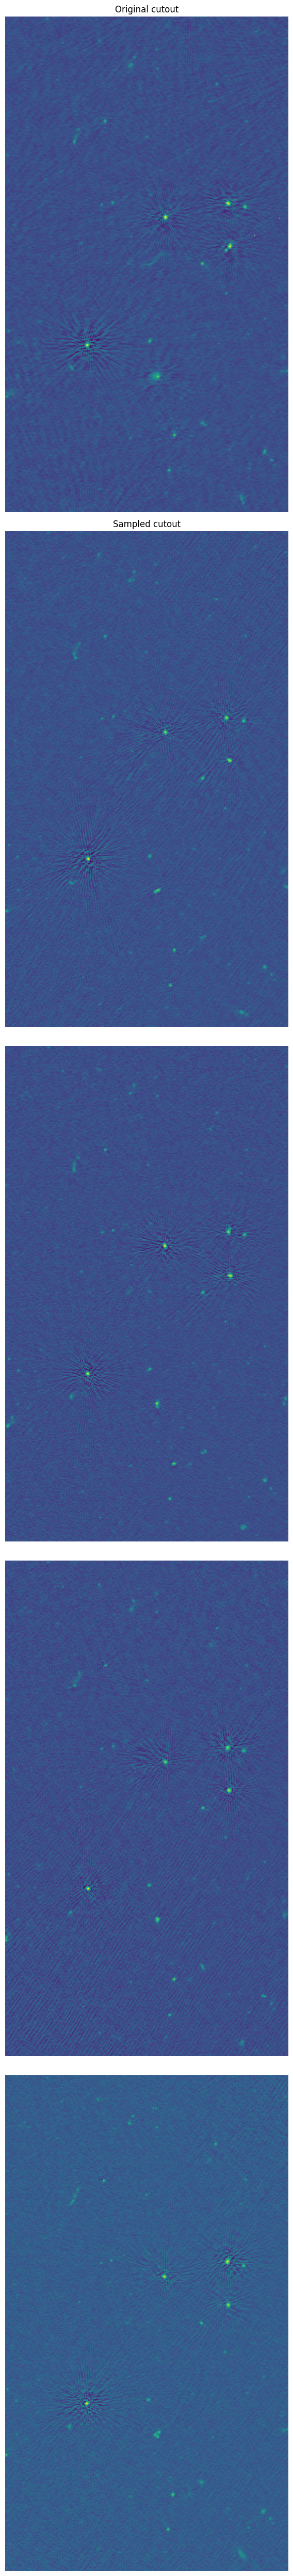

In [28]:
%matplotlib inline
# Define vmin and vmax for consistent color scaling
img_cut_scaled = scaler.scale(img_cut)
vmin = min(np.nanmin(img_cut_scaled), map_sampled.min())
vmax = max(np.nanmax(img_cut_scaled), map_sampled.max())

fig, axs = plot_image_grid(
    [img_cut_scaled, *map_sampled],
    n_cols=1,
    # vmin=vmin,
    # vmax=vmax,
    # figsize=(15, 10),
    img_side_len=10,
)
# Add grid lines to show sampling step boundaries
for ax in axs:
    break
    ax.axis("on")
    ax.set_xticks(
        [i * img_stride for i in range(1, sampling_steps[1] - 1)],
        minor=False,
    )
    ax.set_yticks(
        [i * img_stride for i in range(1, sampling_steps[0] - 1)],
        minor=False,
    )
    ax.set_xticks(
        [image_size + i * img_stride for i in range(0, sampling_steps[1] - 2)],
        minor=True,
    )
    ax.set_yticks(
        [image_size + i * img_stride for i in range(0, sampling_steps[0] - 2)],
        minor=True,
    )
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(which="major", color="white", linestyle="--", linewidth=1, alpha=0.1)
    ax.grid(which="minor", color="white", linestyle="--", linewidth=1, alpha=0.1)

axs[0].set_title("Original cutout")
axs[1].set_title("Sampled cutout")
fig.tight_layout()

In [ ]:
# Load LDM Sampler
import_reload("models.diffusion.diffusion")
import_reload("models.diffusion.sampler")

LDMSampler = import_reload("models.ldm.sampler", attr="LDMSampler")

if False:
    ldm_sampler = LDMSampler(
        denoiser=denoiser,
        denoiser_ckpt=denoiser_ckpt,
        uncond_denoiser=uncond_denoiser,
        uncond_denoiser_ckpt=uncond_denoiser_ckpt,
        vae=vae,
        device=device,
        image_size=image_size,
        latent_size=latent_size,
    )

## Do inspection:

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(vmin, vmax, 100)
hkw = dict(alpha=0.5, bins=bins, histtype="step")
ax.hist(img_cut_scaled.flatten(), **hkw, label="Original cutout")
ax.hist(map_sampled.flatten(), **hkw, label="Sampled cutout")
ax.legend()
ax.grid(alpha=0.3)

ax.set_xlabel("Pixel value")
ax.set_ylabel("Count")

fig.show()

In [ ]:
diff = map_sampled.squeeze() - img_cut_scaled
amax = np.nanmax(np.abs(diff))

plot_image_grid([diff], vmin=-amax, vmax=amax, figsize=(15, 10), cmap="bwr")

#### Plot Original with context map

In [ ]:
# Define vmin and vmax for consistent scaling
fig, axs = plot_image_grid(
    [img_cut_scaled, np.log1p(ctxt_red[2])],
    n_cols=2,
    figsize=(15, 12),
)
# Add grid lines to show quadrants
for ax, gridw in zip(axs, [px_per_quadrant, px_per_quadrant // 4]):
    ax.axis("on")
    ax.set_xticks(
        [i * gridw for i in range(1, quadrant_size[1])],
        minor=False,
    )
    ax.set_yticks(
        [i * gridw for i in range(1, quadrant_size[0])],
        minor=False,
    )
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(which="major", color="white", linestyle="--", linewidth=1, alpha=0.2)

axs[0].set_title("Original cutout")
axs[1].set_title("Reduced Context Map (Fpeak)")
fig.tight_layout()

#### Plot intermediate results

In [ ]:
import pprint

pprint.pprint(list(intermediates.keys()))

In [ ]:
dec_intm = intermediates["decoded_images"].squeeze()

fig, axs = plot_image_grid(
    dec_intm,
    n_cols=sampling_steps[1] + int(resample_first),
    vmin=vmin,
    vmax=vmax,
    figsize=(8, 9),
)
for i, ax in enumerate(axs.flatten()):
    ax.set_title(f"{intermediates['sampling_indices'][i].tolist()}", fontsize="x-small")

In [ ]:
# Make and save an MP4 animation from the first n images with controllable fps + global vmin/vmax
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter


def animate_images_to_mp4(
    images,
    output_mp4=None,
    n_images=None,
    fps=8,
    global_color_scaling=True,
    cmap="viridis",
    interval_ms=None,
    dpi=150,
    figsize=(6, 6),
):
    """
    images: array-like of shape (N, H, W) or list of 2D arrays
    n_images: use first n images (None -> all)
    fps: output frame rate in frames/sec
    vmin/vmax: global color limits across all frames (None -> auto from selected frames)
    interval_ms: preview interval in notebook; default = 1000/fps
    """
    frames = np.asarray(images)
    if frames.ndim != 3:
        raise ValueError(f"`images` must be (N, H, W), got shape={frames.shape}")

    if n_images is not None:
        if n_images <= 0:
            raise ValueError("`n_images` must be > 0")
        frames = frames[: min(n_images, len(frames))]

    if len(frames) == 0:
        raise ValueError("No frames to animate.")

    # Global scaling (same for all frames)
    if global_color_scaling:
        vmin = np.nanmin(frames)
        vmax = np.nanmax(frames)
    else:
        vmin, vmax = None, None

    if interval_ms is None:
        interval_ms = 1000 / fps

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(frames[0], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_axis_off()
    title = ax.set_title(f"Frame 1/{len(frames)}")

    def _update(i):
        im.set_data(frames[i])
        title.set_text(f"Frame {i+1}/{len(frames)}")
        return im, title

    ani = FuncAnimation(
        fig, _update, frames=len(frames), interval=interval_ms, blit=False, repeat=True
    )

    # Save MP4 (requires ffmpeg to be installed on system)
    writer = FFMpegWriter(fps=fps, bitrate=1800)
    if output_mp4 is not None:
        ani.save(output_mp4, writer=writer, dpi=dpi)
    print(
        f"Saved: {output_mp4} | frames={len(frames)} | fps={fps} | vmin={vmin:.4g}, vmax={vmax:.4g}"
    )

    return ani

In [ ]:
from IPython.display import HTML, display

# Example:
ani = animate_images_to_mp4(
    images=intermediates["decoded_images"].squeeze(),  # (N,H,W)
    # output_mp4="icm_intermediates.mp4",
    fps=4,
    figsize=(10, 10),
)
display(HTML(ani.to_jshtml()))

In [ ]:
out_path = paths.ANALYSIS_PARENT / "playground/sliding_window_intermediates.html"
out_path.write_text(ani.to_jshtml(), encoding="utf-8")

#### Plot intermediate contexts

In [ ]:
fig, axs = plot_image_grid(
    np.log1p(intermediates["context"].squeeze()[:, 2]),  # Peak flux channel
    # intermediates["ext_context"].squeeze()[:, 2] > 0,  # Peak flux channel binary
    n_cols=sampling_steps[1] + int(resample_first),
    figsize=(18, 27),
    # cmap="binary_r"
)

for i, ax in enumerate(axs.flatten()):
    ax.set_title(f"{intermediates['sampling_indices'][i].tolist()}", fontsize="x-small")

    ax.axis("on")
    h = intermediates["context"].shape[-2]
    ax.set_xticks([h // 2])
    ax.set_yticks([h // 2])
    ax.grid(ls="--", color="red", alpha=0.3)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

#### Plot intermediate extended contexts

In [ ]:
grid = intermediates["ext_context"].squeeze()

fig, axs = plot_image_grid(
    # np.log1p(grid[:, 2]),  # Peak flux channel log-scaled
    # grid[:, 2] > 0,  # Peak flux channel binary
    grid.reshape(-1, *grid.shape[2:]),  # All channels
    # n_cols=quadrant_size[1] - int(not resample_first),
    n_cols=4,
    figsize=(18, 27),
    # cmap="binary_r"
)
for i, ax in enumerate(axs[:, 0].flatten()):
    ax.set_title(f"{intermediates['quadrant_indices'][i].tolist()}", fontsize="x-small")

    ax.axis("on")
    h = intermediates["ext_context"].shape[-2]
    ax.set_xticks([h * 1 / 4, h * 3 / 4])
    ax.set_yticks([h * 1 / 4, h * 3 / 4])
    ax.grid(ls="--", color="red", alpha=0.3)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

### Look at intermediate mask context

In [ ]:
# Load ldm sampler

In [ ]:
# Extract mask image latents
mask_img_latents = intermediates["mask_image_latent"]

# Collapse step and batch dimensions
mask_img_latents = mask_img_latents.view(-1, *mask_img_latents.shape[2:])

# Decode
mask_img_latents = mask_img_latents.to(device)
mask_imgs_decoded = ldm_sampler.decode_latents(mask_img_latents)

# Clear GPU
mask_img_latents = mask_img_latents.cpu()
torch.cuda.empty_cache()

In [ ]:
# Plot
plot_image_grid(
    mask_imgs_decoded.squeeze(),
    n_cols=quadrant_size[1] - int(not resample_first),
    vmin=vmin,
    vmax=vmax,
    figsize=(8, 9),
)

### Look at extended context encodings

In [ ]:
ext_ctxt_batch.shape

In [ ]:
ext_ctxt_batch = intermediates["ext_context"][:, 0].to(device)
encoder = swiit_sampler.denoiser.model.model.catalog_emb
encoder.to(device)

with torch.no_grad():
    ext_ctxt_emb = encoder(ext_ctxt_batch).cpu().numpy()

encoder.cpu()
ext_ctxt_batch = ext_ctxt_batch.cpu()

In [ ]:
encodings_steps = intermediates["latents"]

# img_grid = torch.stack([encodings_steps.squeeze().mean(axis=1), ext_ctxt_emb.mean(axis=1)])

absmax = np.abs(ext_ctxt_emb).max()

fig, axs = plot_image_grid(
    ext_ctxt_emb.reshape(-1, *ext_ctxt_emb.shape[-2:]),
    n_cols=4,
    vmin=-absmax,
    vmax=absmax,
    cmap="bwr",
)
for i, ax in enumerate(axs.flatten()):
    ax.axis("on")
    h = ext_ctxt_emb.shape[-1]
    ax.set_xticks([h * 1 / 4, h * 3 / 4])
    ax.set_yticks([h * 1 / 4, h * 3 / 4])
    ax.grid(ls="--", color="red", alpha=0.3)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

### Look at denoising steps for every sample

Latents (channel sum):

In [ ]:
denoising_steps = intermediates["encoding_time_steps"]

_ = plot_image_grid(
    denoising_steps.squeeze()
    .sum(axis=2)
    .permute(1, 0, 2, 3)
    .reshape(-1, *denoising_steps.shape[-2:]),
    n_rows=timesteps + 1,
)

Decoded, i.e. image space:

In [ ]:
denoising_steps = intermediates["encoding_time_steps"]
denoising_steps = denoising_steps.squeeze().permute(1, 0, 2, 3, 4)

# Decode (loop through time step dimension)
denoising_steps_img = np.zeros((*denoising_steps.shape[:2], 1, image_size, image_size))

for i, x in tqdm(enumerate(denoising_steps), total=denoising_steps.shape[0]):
    x_dec = ldm_sampler.decode_latents(x.to(device))
    denoising_steps_img[i] = x_dec


# Clear GPU
del x, x_dec
torch.cuda.empty_cache()

In [ ]:
fig, axs = plot_image_grid(
    denoising_steps_img.squeeze().reshape(-1, *denoising_steps_img.shape[-2:]),
    n_rows=timesteps + 1,
)

# Add timestep labels
for i, ax in enumerate(axs[:, 0]):
    ax.axis("on")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f"{timesteps - i}", fontsize="xx-large")

### Experiment: Vary parameters

In [ ]:
np.flip(np.arange(15, 24, step=2))

In [ ]:
import_reload("models.diffusion.diffusion")

# parameters = np.flip(np.arange(0, 27, step=2))
parameters = [16, 15, 14]
samples = []
for parameter in tqdm(parameters, desc="parameter Loop"):
    map_sampled_exp, latent_sampled_exp = swiit_sampler.sample(
        ctxt_map=torch.from_numpy(ctxt_red).to(torch.float32),
        # ext_ctxt_map=torch.from_numpy(ext_ctxt_red).to(torch.float32),
        guidance_strength=guidance_strength,
        save_intermediates=False,
        timesteps=timesteps,
        seed_noise_map=seed_noise_map,
        # timesteps=2,
        drop_inpainting_ctxt_at=parameter,
        resample_first=resample_first,
        use_latent_ctxt=True,
        verbose=True,
    )
    samples.append(map_sampled_exp.squeeze())

In [ ]:
# Save before anything destroys my precious results
out_path = paths.ANALYSIS_PARENT / "icm_sampling_dev"
out_path.mkdir(exist_ok=True, parents=True)

payload = {
    "samples": np.array(samples),
    "t_drop_values": parameters,
}
np.save(
    out_path / "inpainting_context_tdrop_variation_samples.npy",
    payload,
    allow_pickle=True,
)

In [ ]:
diffs = [samples[(i + 1) % len(samples)] - samples[i] for i in range(len(samples))]

In [ ]:
fig, axs = plot_image_grid(samples, n_cols=1, img_side_len=10)

for i in range(len(samples)):
    axs[i].set_title(f"t_drop = {parameters[i]}")

In [ ]:
diff_to_main = np.array([s - map_sampled.squeeze() for s in samples])
amax = np.nanmax(np.abs(diff_to_main))

plot_image_grid(
    diff_to_main,
    n_cols=1,
    img_side_len=10,
    vmin=-amax,
    vmax=amax,
    cmap="bwr",
)

In [ ]:
plot_grid = np.array(
    [arr for s, d in zip(samples, diffs) for arr in [s, d]]
    + [img_cut_scaled]
    # samples + [img_cut_scaled] + diffs
)

fig, axs = plot_image_grid(
    plot_grid,
    n_rows=len(samples) + 1,
    vmin=np.nanmin(plot_grid),
    vmax=np.nanmax(plot_grid),
)

# Add parameter to rows as ylabel

for i in range(len(samples)):
    ax = axs[i][0]
    ax.axis("on")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f"{parameters[i]}", fontsize="xx-large")

In [ ]:
plt.plot([np.abs(d).sum() for d in diffs])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# images: list/array of 2D arrays
# Example:
# images = [np.random.rand(64, 64) for _ in range(50)]


def make_image_player(
    images,
    global_vmin=None,
    global_vmax=None,
    per_image_vmin=None,
    per_image_vmax=None,
    titles=None,
    figsize=(5, 5),
):
    n = len(images)
    idx = 0
    playing = False
    timer = None

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    def get_vmin(i):
        return per_image_vmin[i] if per_image_vmin is not None else global_vmin

    def get_vmax(i):
        return per_image_vmax[i] if per_image_vmax is not None else global_vmax

    im = ax.imshow(
        images[0],
        vmin=get_vmin(0),
        vmax=get_vmax(0),
        animated=True,
    )
    if titles is not None:
        title_text = ax.set_title(titles[0])

    def show(i):
        im.set_data(images[i])
        im.set_clim(get_vmin(i), get_vmax(i))
        if titles is not None:
            title_text.set_text(titles[i])
        fig.canvas.draw_idle()

    def step(delta):
        nonlocal idx
        idx = (idx + delta) % n
        slider.value = idx
        show(idx)

    def on_slider_change(change):
        nonlocal idx
        idx = change["new"]
        show(idx)

    def on_speed_change(change):
        nonlocal timer
        if timer is not None:
            timer.stop()
            timer = fig.canvas.new_timer(interval=change["new"])
            timer.add_callback(on_timer)
            if playing:
                timer.start()

    def on_timer():
        if playing:
            step(1)

    def on_play_click(_):
        nonlocal playing, timer
        playing = True
        if timer is None:
            timer = fig.canvas.new_timer(interval=speed.value)
            timer.add_callback(on_timer)
        timer.start()

    def on_pause_click(_):
        nonlocal playing
        playing = False
        if timer is not None:
            timer.stop()

    slider = widgets.IntSlider(value=0, min=0, max=n - 1, step=1, description="Frame")
    speed = widgets.IntSlider(
        value=200, min=50, max=2000, step=50, description="ms/frame"
    )
    btn_play = widgets.Button(description="Play")
    btn_pause = widgets.Button(description="Pause")
    btn_prev = widgets.Button(description="⟵")
    btn_next = widgets.Button(description="⟶")

    slider.observe(on_slider_change, names="value")
    speed.observe(on_speed_change, names="value")
    btn_play.on_click(on_play_click)
    btn_pause.on_click(on_pause_click)
    btn_prev.on_click(lambda _: step(-1))
    btn_next.on_click(lambda _: step(1))

    controls = widgets.HBox([btn_play, btn_pause, btn_prev, btn_next, speed])
    display(fig)
    display(controls, slider)

    return fig, ax


# Usage:
# make_image_player(images, global_vmin=0, global_vmax=1)
# or per-image:
# make_image_player(images, per_image_vmin=[...], per_image_vmax=[...])

In [ ]:
%matplotlib widget
samples = np.array(samples)
_ = make_image_player(
    samples,
    global_vmin=np.nanmin(samples),
    global_vmax=np.nanmax(samples),
    titles=[f"Parameter: {p}" for p in parameters],
    figsize=(8, 8),
)

### Experiment: Re-sample with inpainting context drop

In [ ]:
intermediates["sampling_masks"].shape, intermediates[
    "mask_image_latent"
].shape, intermediates["context"].shape

In [ ]:
import_reload("models.diffusion.diffusion")

t_drop_values = [26]

for t_drop in tqdm(t_drop_values, desc="t_drop Loop"):
    resampled_step_imgs, resampled_step_latents = ldm_sampler.sample(
        context=intermediates["context"].squeeze(),
        catalog_context=intermediates["ext_context"].squeeze(),
        mask_input=(
            intermediates["sampling_masks"].squeeze(dim=1),
            intermediates["mask_image_latent"].squeeze(dim=1),
        ),  # This is the change
        rescale=False,
        return_latents=True,
        latents=intermediates["seed_noise"].squeeze(),
        guidance_strength=0.2,
        # timesteps=25,
        drop_inpainting_ctxt_at=t_drop,
    )

Plot intermediates and re-sampled side by side for comparison

In [ ]:
# Stack images so that we can plot the grid
# with corresponding pairs next to each other
from math import prod

step_imgs = intermediates["decoded_images"]
n_sampled = tuple(n + int(resample_first) for n in sampling_steps)

# Divide original into tiles so we can plot the originals
original_step_imgs = np.stack(
    [
        img_cut_scaled[
            row * img_stride : image_size + row * img_stride,
            col * img_stride : image_size + col * img_stride,
        ]
        for row in range(n_sampled[1])
        for col in range(n_sampled[0])
    ]
)

# Stack image grid
img_grid = (
    np.stack(
        [step_imgs.squeeze(), resampled_step_imgs.squeeze(), original_step_imgs], axis=1
    )
    .reshape(n_sampled[1], n_sampled[0], 3, *step_imgs.squeeze().shape[1:])
    .transpose(0, 2, 1, 3, 4)
    .reshape(3 * n_sampled[1] * n_sampled[0], *step_imgs.squeeze().shape[1:])
)

# Make plot
fig, axs = plot_image_grid(
    img_grid, n_cols=n_sampled[1], vmin=vmin, vmax=vmax, figsize=(14, 32)
)

# Add grid
for ax in axs.flatten():
    ax.axis("on")
    ax.set_xticks(
        [img_mask_overlap],
        minor=False,
    )
    ax.set_yticks(
        [img_mask_overlap],
        minor=False,
    )
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(which="major", color="white", linestyle="--", linewidth=1, alpha=0.1)

# Add titles/labels
for i, t in enumerate((intermediates["sampling_indices"])):
    ax = axs[::3].flatten()[i]
    ax.set_title(f"{t.tolist()}")
    if i % n_sampled[1] == 0:
        kw = dict(fontsize="large")
        ax.set_ylabel("ICM Sampled", **kw)
        ax1 = axs[1::3].flatten()[i]
        ax1.set_ylabel("Re-sampled", **kw)
        ax2 = axs[2::3].flatten()[i]
        ax2.set_ylabel("Original", **kw)

### Experiment: Re-sample quadrants without image & mask context

#### All steps

In [ ]:
import_reload("models.diffusion.diffusion")

# Re-sample without image & mask ctxt
resampled_step_imgs, resampled_step_latents = ldm_sampler.sample(
    context=intermediates["context"].squeeze(),
    catalog_context=intermediates["ext_context"].squeeze(),
    mask_input=None,  # This is the change
    rescale=False,
    return_latents=True,
    latents=intermediates["seed_noise"].squeeze(),
    guidance_strength=0.2,
    # timesteps=25,
)

Plot intermediates and re-sampled side by side for comparison

In [ ]:
# Stack images so that we can plot the grid
# with corresponding pairs next to each other
from math import prod

step_imgs = intermediates["decoded_images"]
n_sampled = tuple(n + int(resample_first) for n in sampling_steps)

# Divide original into tiles so we can plot the originals
original_step_imgs = np.stack(
    [
        img_cut_scaled[
            row * img_stride : image_size + row * img_stride,
            col * img_stride : image_size + col * img_stride,
        ]
        for row in range(n_sampled[1])
        for col in range(n_sampled[0])
    ]
)

# Stack image grid
img_grid = (
    np.stack(
        [step_imgs.squeeze(), resampled_step_imgs.squeeze(), original_step_imgs], axis=1
    )
    .reshape(n_sampled[1], n_sampled[0], 3, *step_imgs.squeeze().shape[1:])
    .transpose(0, 2, 1, 3, 4)
    .reshape(3 * n_sampled[1] * n_sampled[0], *step_imgs.squeeze().shape[1:])
)

# Make plot
fig, axs = plot_image_grid(
    img_grid, n_cols=n_sampled[1], vmin=vmin, vmax=vmax, figsize=(14, 32)
)

# Add grid
for ax in axs.flatten():
    ax.axis("on")
    ax.set_xticks(
        [img_mask_overlap],
        minor=False,
    )
    ax.set_yticks(
        [img_mask_overlap],
        minor=False,
    )
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(which="major", color="white", linestyle="--", linewidth=1, alpha=0.1)

# Add titles/labels
for i, t in enumerate((intermediates["sampling_indices"])):
    ax = axs[::3].flatten()[i]
    ax.set_title(f"{t.tolist()}")
    if i % n_sampled[1] == 0:
        kw = dict(fontsize="large")
        ax.set_ylabel("ICM Sampled", **kw)
        ax1 = axs[1::3].flatten()[i]
        ax1.set_ylabel("Re-sampled", **kw)
        ax2 = axs[2::3].flatten()[i]
        ax2.set_ylabel("Original", **kw)

In [ ]:
plot_image_grid(original_step_imgs)

In [ ]:
# Calculate differences
diffs = (step_imgs - resampled_step_imgs).squeeze()

fig, axs = plot_image_grid(
    diffs, n_cols=quadrant_size[1], vmin=diffs.min(), vmax=diffs.max(), cmap="bwr"
)

for i, t in enumerate((intermediates["quadrant_indices"])):
    ax = axs.flatten()[i]
    ax.set_title(f"{t.tolist()}")

#### Single step

Extract step information from intermediates

In [ ]:
# Index of which step to resample
i_step = -1

step_img = intermediates["decoded_images"][i_step].squeeze()
ctxt = intermediates["context"][i_step]
ext_ctxt = intermediates["ext_context"][i_step]
mask = intermediates["sampling_masks"][i_step]
seed_noise = intermediates["seed_noise"][i_step]

Re-sample with same context and seed noise

In [ ]:
resampled_step_img = ldm_sampler.sample(
    context=ctxt,
    catalog_context=ext_ctxt,
    rescale=False,
    return_latents=False,
)

In [ ]:
fig, axs = plot_image_grid(
    [
        step_img,
        resampled_step_img.squeeze(),
    ],
    n_cols=2,
    vmin=vmin,
    vmax=vmax,
)

### Experiment: Sample without inpainting context

In [ ]:
map_sampled_exp, latent_sampled_exp, intermediates_exp = swiit_sampler.sample(
    ctxt_map=torch.from_numpy(ctxt_red).to(torch.float32),
    guidance_strength=guidance_strength,
    save_intermediates=True,
    timesteps=timesteps,
    use_latent_ctxt=True,
    drop_inpainting_ctxt_at=26,
    seed_noise_map=seed_noise_map,
    resample_first=resample_first,
)

In [ ]:
%matplotlib inline

# Define vmin and vmax for consistent scaling
img_cut_scaled = swiit_sampler.scaler.scale(img_cut)
vmin = min(np.nanmin(img_cut_scaled), map_sampled.min())
vmax = max(np.nanmax(img_cut_scaled), map_sampled.max())

fig, axs = plot_image_grid(
    [img_cut_scaled, map_sampled_exp.squeeze()],
    n_cols=1,
    vmin=vmin,
    vmax=vmax,
    figsize=(10, 15),
)
# Add grid lines to show quadrants
for ax in axs:
    break
    ax.axis("on")
    ax.set_xticks(
        [i * img_stride for i in range(1, sampling_steps[1] - 1)],
        minor=False,
    )
    ax.set_yticks(
        [i * img_stride for i in range(1, sampling_steps[0] - 1)],
        minor=False,
    )
    ax.set_xticks(
        [image_size + i * img_stride for i in range(0, sampling_steps[1] - 2)],
        minor=True,
    )
    ax.set_yticks(
        [image_size + i * img_stride for i in range(0, sampling_steps[0] - 2)],
        minor=True,
    )
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(which="major", color="white", linestyle="--", linewidth=1, alpha=0.1)
    ax.grid(which="minor", color="white", linestyle="--", linewidth=1, alpha=0.1)

axs[0].set_title("Original cutout")
axs[1].set_title("Sampled cutout")
fig.tight_layout()

Re-sample single steps for comparison

In [ ]:
# Re-sample without image & mask ctxt
resampled_step_imgs_exp, resampled_step_latents_exp = ldm_sampler.sample(
    context=intermediates_exp["context"].squeeze(),
    catalog_context=intermediates_exp["ext_context"].squeeze(),
    mask_input=None,  # This is the change
    rescale=False,
    return_latents=True,
    latents=intermediates_exp["seed_noise"].squeeze(),
    # timesteps=25,
)

Plot intermediates and re-sampled side by side for comparison

In [ ]:
# Stack images so that we can plot the grid
# with corresponding pairs next to each other
from math import prod

step_img_exp = intermediates_exp["decoded_images"]
n_sampled = tuple(q - int(not resample_first) for q in quadrant_size)

# Divide original into tiles so we can plot the originals
original_step_imgs = np.stack(
    [
        img_cut_scaled[
            row * px_per_quadrant : (row + 2) * px_per_quadrant,
            col * px_per_quadrant : (col + 2) * px_per_quadrant,
        ]
        for row in range(n_sampled[1])
        for col in range(n_sampled[0])
    ]
)

# Stack image grid
img_grid = (
    np.stack(
        [step_img_exp.squeeze(), resampled_step_imgs_exp.squeeze(), original_step_imgs],
        axis=1,
    )
    .reshape(n_sampled[1], n_sampled[0], 3, *step_img_exp.squeeze().shape[1:])
    .transpose(0, 2, 1, 3, 4)
    .reshape(3 * n_sampled[1] * n_sampled[0], *step_img_exp.squeeze().shape[1:])
)

# Make plot
fig, axs = plot_image_grid(
    img_grid, n_cols=n_sampled[1], vmin=vmin, vmax=vmax, figsize=(14, 32)
)

# Add grid
for ax in axs.flatten():
    ax.axis("on")
    ax.set_xticks(
        [px_per_quadrant],
        minor=False,
    )
    ax.set_yticks(
        [px_per_quadrant],
        minor=False,
    )
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(which="major", color="white", linestyle="--", linewidth=1, alpha=0.1)

# Add titles/labels
for i, t in enumerate((intermediates_exp["quadrant_indices"])):
    ax = axs[::3].flatten()[i]
    ax.set_title(f"{t.tolist()}")
    if i % n_sampled[1] == 0:
        kw = dict(fontsize="large")
        ax.set_ylabel("ICM Sampled", **kw)
        ax1 = axs[1::3].flatten()[i]
        ax1.set_ylabel("Re-sampled", **kw)
        ax2 = axs[2::3].flatten()[i]
        ax2.set_ylabel("Original", **kw)

Plot intermediate results

In [ ]:
fig, axs = plot_image_grid(
    intermediates_exp["decoded_images"].squeeze(),
    n_cols=5,
    vmin=vmin,
    vmax=vmax,
    figsize=(8, 9),
)
for i, ax in enumerate(axs.flatten()):
    ax.set_title(f"{intermediates['quadrant_indices'][i].tolist()}", fontsize="x-small")

### Image pixel stats

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# Pixel counts
bin_limit = 0.1
bins = np.linspace(-bin_limit, bin_limit, 100)
kw = dict(bins=bins, log=True, histtype="step")
ax.hist(img_cut_scaled.flatten(), label="Original Image", **kw)

# Sampled map counts
ax.hist(map_sampled.flatten(), label="Sampled Map", **kw)
# Individual resampled steps counts
ax.hist(resampled_step_imgs.flatten(), label="Resampled Steps", **kw)

ax.grid(alpha=0.3)
ax.set_xlabel("Scaled Pixel Value")
ax.set_ylabel("Count")
ax.legend()

fig.show()

### Experiment: Investigate Single-Image Resampling Degradation

Helper Functions

In [ ]:
# Function for tiling an array into n_tiles
def tile_array(arr, n_tiles):
    """
    Split an array into tiles. Handles arrays with optional batch and channel dimensions.

    Args:
        arr: Array to tile. Last 2 dimensions are assumed to be (H, W).
             Supports: (H, W), (C, H, W), (B, C, H, W), etc.
        n_tiles: Total number of tiles (must be a perfect square)

    Returns:
        Tiled array with shape (..., n_side, n_side, tile_h, tile_w)
        where ... represents any leading dimensions (batch, channels, etc.)
    """
    n_side = int(np.sqrt(n_tiles))
    if n_side**2 != n_tiles:
        raise ValueError(f"n_tiles must be a perfect square, got {n_tiles}")

    # Image size should be divisible by n_side
    h, w = arr.shape[-2], arr.shape[-1]
    if h % n_side != 0 or w % n_side != 0:
        raise ValueError(
            f"Image size ({h}, {w}) must be divisible by n_side ({n_side})"
        )

    # Get spatial dimensions (last 2)
    *leading_dims, h, w = arr.shape
    tile_h = h // n_side
    tile_w = w // n_side

    # Reshape: (..., n_side, tile_h, n_side, tile_w)
    reshape_dims = (*leading_dims, n_side, tile_h, n_side, tile_w)
    tiles = arr.reshape(reshape_dims)

    # Transpose to: (..., n_side, n_side, tile_h, tile_w)
    n_leading = len(leading_dims)
    transpose_axes = (
        n_leading,  # n_side (rows)
        n_leading + 2,  # n_side (cols)
        *range(n_leading),  # Leading dims
        n_leading + 1,  # tile_h
        n_leading + 3,  # tile_w
    )
    tiles = tiles.transpose(transpose_axes)

    # Collapse n_side dims
    tiles = tiles.reshape(n_tiles, *leading_dims, tile_h, tile_w)

    return tiles


# Function for making sampling mask at n-th iteration,
# if we're doing left-right flipping
def sampling_mask_left_right(it, size=latent_size):

    # Prepare mask (1 means quadrant will be sampled)
    if it == 0:
        # Beginning: Sample all
        mask = torch.tensor([1, 1, 1, 1])
    elif it % 2 == 0:
        # Even number: Sample left
        mask = torch.tensor([1, 0, 1, 0])
    else:
        # Odd number: Sample right
        mask = torch.tensor([0, 1, 0, 1])

    # Make square
    mask = mask.reshape(1, 1, 2, 2).float()
    # Upscale to size
    mask = torch.nn.functional.interpolate(mask, scale_factor=size // 2, mode="nearest")
    return mask


# Function for making sampling mask at n-th iteration,
# if we're doing corner circling
def sampling_mask_corner_circling(it, size=latent_size):
    # Prepare mask (1 means quadrant will be sampled)
    if it == 0:
        # Beginning: Sample all
        mask = torch.tensor([1, 1, 1, 1])
    else:
        # Starting with top-right, circling clockwise
        mod4 = it % 4
        mask = torch.tensor(
            [int(mod4 == 0), int(mod4 == 1), int(mod4 == 3), int(mod4 == 2)]
        )

    # Make square
    mask = mask.reshape(1, 1, 2, 2).float()
    # Upscale to size
    mask = torch.nn.functional.interpolate(mask, scale_factor=size // 2, mode="nearest")
    return mask

Extract larger cutout that will be tiled

In [ ]:
# Define tile cutout size
n_tiles = 4
tiles_cut_size_px = int(np.sqrt(n_tiles)) * image_size

# Get mosaic blueprint
img_cut_tiles, ctxt_red_tiles, ctxt_cat_tiles = get_mosaic_blueprint(
    mosaic, tiles_cut_size_px, cat=lotss_cat
)

# Tile the arrays
img_cut_tiled = tile_array(img_cut_tiles, n_tiles)
ctxt_red_tiled = tile_array(ctxt_red_tiles, n_tiles)

# Getting the catalog context is a bit complicated:
# Get padded context
_, cat_ctxt_red_tiles, _ = get_mosaic_blueprint(
    mosaic, tiles_cut_size_px + image_size, cat=lotss_cat, f_downscale=2
)
# Tiling with overlap: Use icm_sampler logic
cat_ctxt_red_tiled = []
for i in range(1, 2 * int(np.sqrt(n_tiles)), 2):
    for j in range(
        1, 2 * int(np.sqrt(n_tiles)), 2
    ):  # Double step bc. ICMSampler works with quadrants
        # Get slices
        sl_row, sl_col = swiit_sampler.extended_context_slices(i, j)
        # Extract and store
        cat_ctxt_red_tiled.append(cat_ctxt_red_tiles[:, sl_row, sl_col])
cat_ctxt_red_tiled = np.array(cat_ctxt_red_tiled)
# Zero-out center
zero_padw = latent_size // 2
cat_ctxt_red_tiled[:, :, zero_padw:-zero_padw, zero_padw:-zero_padw] *= 0

In [ ]:
# Plot for sanity check
fig, ax = plot_image_grid([ldm_sampler.px_scaler.scale(img_cut_tiles)], img_side_len=10)
# Activate grid that shows tiling
ax.axis("on")
ax.set_xticks(image_size * np.arange(1, int(np.sqrt(n_tiles))))
ax.set_yticks(image_size * np.arange(1, int(np.sqrt(n_tiles))))
ax.grid(ls="--", color="red", alpha=0.3)
ax.set_xticklabels([])
ax.set_yticklabels([])

_ = plot_image_grid(ldm_sampler.px_scaler.scale(img_cut_tiled))
fig, axs = plot_image_grid(np.log1p(cat_ctxt_red_tiled[:, 2]))
for ax in axs.flatten():
    ax.axis("on")
    h = cat_ctxt_red_tiled.shape[-2]
    ax.set_xticks([h * 1 / 4, h * 3 / 4])
    ax.set_yticks([h * 1 / 4, h * 3 / 4])
    ax.grid(ls="--", color="red", alpha=0.3)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

Set up loop and run

In [ ]:
# Settings
n_laps = 5
resampling_pattern = "left_right"  # "left_right" or "circling"

# Sampling setup
match resampling_pattern:
    case "left_right":
        it_per_round = 2
        mask_fn = sampling_mask_left_right

    case "circling":
        it_per_round = 4
        mask_fn = sampling_mask_corner_circling

# Prepare Loop
lap_samples = np.zeros((n_laps + 1, *img_cut_tiled.shape), dtype=np.float32)
current_img_batch = img_cut_tiled.copy()
current_latent_batch = np.zeros((n_tiles, 3, latent_size, latent_size))
context = torch.from_numpy(ctxt_red_tiled).to(torch.float32).to(device)
catalog_context = torch.from_numpy(cat_ctxt_red_tiled).to(torch.float32).to(device)
noise = torch.randn(current_latent_batch.shape).to(device)


# Sampling loop
for it in trange(n_laps * it_per_round + 1, desc="Sampling Loop"):
    # Get sampling mask for this iteration
    sampling_mask = mask_fn(it, size=latent_size).repeat(n_tiles, 1, 1, 1).to(device)

    # Sample tiles
    current_img_batch, current_latent_batch = ldm_sampler.sample(
        mask_input=(
            sampling_mask,
            torch.from_numpy(current_latent_batch).to(device, dtype=torch.float32),
        ),
        context=context,
        catalog_context=catalog_context,
        guidance_strength=guidance_strength,
        timesteps=timesteps,
        rescale=False,
        return_latents=True,
        latents=noise,
    )

    if it % it_per_round == 0:
        print(f"Completed lap {it // it_per_round}")
        lap_idx = it // it_per_round
        lap_samples[lap_idx] = current_img_batch.squeeze()

# Free GPU
del current_latent_batch, current_img_batch, context, catalog_context, sampling_mask
torch.cuda.empty_cache()

In [ ]:
lap_samples.shape

In [ ]:
# Plot samples with original
plot_grids = np.concatenate(
    [
        ldm_sampler.px_scaler.scale(img_cut_tiled).reshape(1, *img_cut_tiled.shape),
        lap_samples,
    ],
    axis=0,
).transpose(1, 0, 2, 3)

vmin, vmax = np.nanmin(plot_grids), np.nanmax(plot_grids)
for i, grid in enumerate(plot_grids):
    fig, axs = plot_image_grid(
        grid, n_cols=n_laps + 2, vmin=vmin, vmax=vmax, img_side_len=3
    )
    fig.suptitle(f"Tile {i + 1}")

In [ ]:
np.concatenate(
    [
        ldm_sampler.px_scaler.scale(img_cut_tiled).reshape(1, *img_cut_tiled.shape),
        lap_samples,
    ],
    axis=0,
).shape

## Sample unconditioned:

In [ ]:
# Use for reproducibility
batch_size_uncond = 25
seed_noise = torch.randn(batch_size_uncond, 3, latent_size, latent_size)

In [ ]:
uncond_samples, uncond_latents = ldm_sampler.sample(
    context=None,
    catalog_context=None,
    mask_input=None,
    rescale=False,
    return_latents=True,
    latents=seed_noise,
    guidance_strength=-1,
    n_samples=batch_size_uncond,
)

In [ ]:
%matplotlib inline
_ = plot_image_grid(
    uncond_samples.squeeze(),
    # vmin=uncond_samples.min(),
    # vmax=uncond_samples.max(),
    # figsize=(10, 10),
)